In [31]:
## Packages Import
import copy
import numpy             as np
import matplotlib.pyplot as plt

In [32]:
class VLMPanel:
    """
    Vortex Lattice Method panel with horseshoe vortex
    """
    #--------------------#
    #   Initialization   #
    #--------------------#
    def __init__(self, p, b):
        """
        Panel is of quadrilateral shape and vertices must be ordered from root
        position on leading-edge proceeding in counterclockwise direction. 
        """
        # Wing geometry
        self.span = b       # wing span [m]

        # Panel geometry
        self.pnt    = p        # panel vertices
        self.ctr    = None     # control point
        self.normal = None     # normal direction
        self.chord  = None     # chord length [m]
        self.width  = None     # pannel width [m]
        self.area   = None     # panel area   [m**2]

        # Vortex parameters
        self.vrt = None     # horseshoe vortex points
        
        self._get_panel_geom()
        self._get_vortex_geom(20*b)


    #-------------#
    #   Methods   #
    #-------------#
    def _get_panel_geom(self):
        """
        Compute panel geometric parameters such as control point position, normal
        versor, chord length, width and area, starting from panel's vertices.
        """
        p = self.pnt

        # Compute representative panel's geometric parameters
        c_avg = 0.5 * (np.linalg.norm(p[2] - p[1]) + np.linalg.norm(p[3] - p[0]))  # average chord length
        w_avg = 0.5 * (np.linalg.norm(p[2] - p[3]) + np.linalg.norm(p[1] - p[0]))  # average width

        # Compute position of control point
        cp = (p[0] + p[1] + 3*p[3] + 3*p[2])/8    # three-quarter line


        # Compute normal versor and panel surface
        ai = np.zeros(3)
        for i, pi in enumerate(p):
            qi = p[(i + 1) % len(p)]
            ai += np.cross(pi, qi)

        av = 0.5 * ai
        a = np.linalg.norm(av)
        if a > 0.0:
            n = av / a
        else:
            # Degenerate cells with zero area
            print(f"Degenerate panel {i} with {len(p)} vertices")

        self.ctr    = cp
        self.normal = n
        self.chord  = c_avg
        self.width  = w_avg
        self.area   = a

    def _get_vortex_geom(self, d):
        """
        Compute horseshoe vortex's vertices position starting from panel's vertices.
        Horseshoe vortex is approximated by a ring vortex with negligible contribution
        by the wake vortex.

        Input:
        d -> wake vortex distance from wing
        """
        p = self.pnt

        v = []
        for i, pi in enumerate(p):
            vi = np.copy(pi)
            if i in [0, 1]:
                # Bound vortex lies on the quater chord line
                vi[0] += (0.25 * self.chord)
            elif i in [2, 3]:
                # Wake vortex lies far behind the wing
                vi[0] += d   # HP: trailing vortices parallel to x-axis
            v.append(vi)

        self.vrt = v

In [33]:
class VLMSolver:
    """
    Vortex Lattice Method solver
    """
    #--------------------#
    #   Initialization   #
    #--------------------#
    def __init__(self, b, c, alpha, lamb, delta, sym,
                u_inf, n):
        # Wing geometry
        self.span     = b       # wing span                 [m]
        self.chord    = c       # chord lengths             [m]
        self.aoa      = alpha   # angle of attack           [rad]
        self.sweep    = lamb    # quarter-chord sweep angle [rad]
        self.dihedron = delta   # dihedral angle            [rad]
        self.symmetric = sym    # symmetric wing

        # Flow properties
        self.U = u_inf      # inflow velocity [m/s]

        # Discretization
        self.N = n              # number of panels
        self.panels = None      # panel objects

        # Linear system
        self.A = None       # coefficient matrix
        self.b = None       # right hand side

    
    #-------------#
    #   Methods   #
    #-------------#
    def _unit_rot(self, v, theta, ax):
        """
        Elemental clockwise rotation of the reference system axes.
        
        Input:
        v     -> vector componets - shape: (N, 3)
        theta -> rotation angle - clockwise rotation: theta>0
        ax    -> rotation axis index
        """
        # Assemble rotation matrix
        rot = np.zeros((3, 3))  # rotation matrix
        # diagonal elements
        rot[ax, ax] = 1.0
        rot[ax-1, ax-1] = np.cos(theta)
        rot[ax-2, ax-2] = np.cos(theta)
        # extra-diagonal elements
        rot[ax-2, ax-1] = -np.sin(theta)
        rot[ax-1, ax-2] = np.sin(theta)

        # Apply rotation
        v_rot = np.sum(rot[None, :, :] * v[:, None, :], axis=2)
        return v_rot


    def _build_mesh(self):
        """
        Discretization of the wing by a finite number of lattices.
        """
        n     = self.N
        b     = self.span
        alpha = self.aoa
        lamb  = self.sweep
        delta = self.dihedron
        c     = self.chord

        # Leading-edge length of the semi-wing
        le = (0.5 * b) /  np.cos(delta)
        if self.symmetric:
            s_min, s_max = 0.0, le
        else:
            s_min, s_max = -le, le

        # Spanwise wing discretization
        s = np.linspace(s_min, s_max, (n+1))    # leading-edge coordinates

        # Change reference system for leading-edge coordinates
        le_wing  = np.column_stack((np.zeros_like(s), np.zeros_like(s), s))                 # wing frame
        le_swept = np.column_stack((le_wing[:,2]*np.tan(lamb),le_wing[:,1],le_wing[:,2]))   # swept frame
        le_yaw   = self._unit_rot(le_swept, -delta, 0)                                      # yawed frame
        le_earth = self._unit_rot(le_yaw,  -alpha, 2)                                       # earth frame
        # Compute trailing-edge coordinates
        te_wing  = np.column_stack((c, np.zeros_like(c), s))                                            # wing frame
        te_swept = np.column_stack((te_wing[:,2]*np.tan(lamb)+te_wing[:,0],te_wing[:,1],te_wing[:,2]))  # swept frame
        te_yaw = self._unit_rot(te_swept, -delta, 0)                                                    # yawed frame
        te_earth = self._unit_rot(te_yaw, -alpha, 2)                                                    # earth frame
    
        panels = []     # list of panel objects
        for i in range(n):
            pnt = [le_earth[i],
                le_earth[i+1],
                te_earth[i+1],
                te_earth[i]]    # ordered panel vertices

            panels.append(VLMPanel(p=pnt, b=b))

        self.panels = panels


In [34]:
## Utilities

def chord_fn(n, c0, shape="rectangular"):
    """
    Return chord length distribution along spanwise direction according to the
    desired planform shape.

    Input:
        n     -> number of grid points
        c0    -> root chord length
        shape -> wing planform
    """
    match shape:
        case "rectangular":
            c = c0 * np.ones(n)
        # case "elliptical":
        #     c = c0 * np.sqrt(1 - (z/s)**2)
    return c

In [35]:
## Parameters Definition

# Wing geometry
B = 1.0         # wing span                 [m]
AR = 5.0        # aspect ration             [-]
ALPHA  = 8.0    # angle of attck            [deg] - positive definite for counterclockwise rotations about z-axis
LAMBDA = 30     # quarter-chord sweep angle [deg] - positive definite for counterclockwise rotations about x-axis
DELTA  = 10     # dihedral angle            [deg] - positive definite for rotations oriented towards positive y-axis

SYM = True   # symmetric wing configuration

# Flow properties
U = 1.0     # inflow velocity [m/s]

# Wing discretization
N = 4       # number of panels in spanwise direction

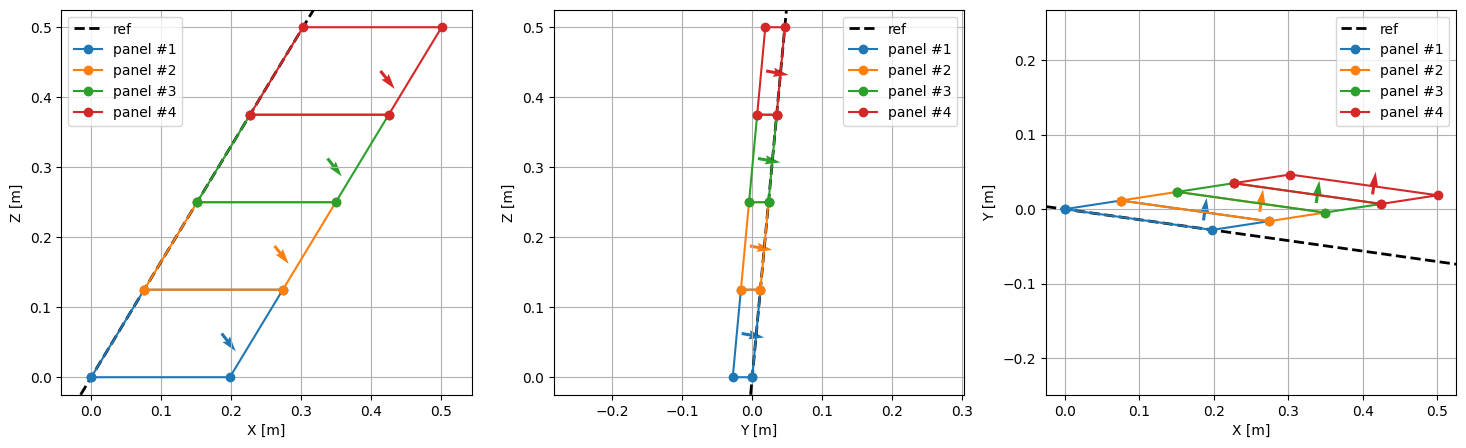

In [36]:
## TEST

# Untapered wing (constant chord length distribution)
c0 = B / AR     # chord length [m]

# Wing discretization and attitude
vlm = VLMSolver(b=B,
                c=chord_fn((N+1), c0),
                alpha=np.deg2rad(ALPHA),
                lamb=np.deg2rad(LAMBDA),
                delta=np.deg2rad(DELTA),
                sym=SYM,
                u_inf=np.array([U, 0.0, 0.0]),
                n=N)
vlm._build_mesh()


fig_test = plt.figure(figsize=(18, 5))
ax1 = fig_test.add_subplot(1, 3, 1)
ax2 = fig_test.add_subplot(1, 3, 2)
ax3 = fig_test.add_subplot(1, 3, 3)


for i, panel in enumerate(vlm.panels):
    pnt    = copy.copy(panel.pnt)
    ctr    = copy.copy(panel.ctr)
    normal = copy.copy(panel.normal)
    vrt    = copy.copy(panel.vrt)
    # Close the polygon shape
    pnt.append(pnt[0])
    pnt_plt = np.array(pnt)
    vrt.append(vrt[0])
    vrt_plt = np.array(vrt)

    if i == 0:
        # Create a reference vector
        vref=np.array([[np.tan(np.deg2rad(LAMBDA)), 0, 1]])
        vref=vlm._unit_rot(vref,-np.deg2rad(DELTA),0)
        vref=vlm._unit_rot(vref,-np.deg2rad(ALPHA),2)
        # Plot reference direction
        ax1.axline(pnt_plt[0, :2:],  slope=np.tan(np.deg2rad(90)-np.atan(vref[0,0]/vref[0,2])), c='k', lw=2, ls='--', label="ref")
        ax2.axline(pnt_plt[0, 1::],  slope=np.tan(np.deg2rad(90)-np.atan(vref[0,1]/vref[0,2])),  c='k', lw=2, ls='--', label="ref")
        ax3.axline(pnt_plt[0, ::-2], slope=np.tan(np.deg2rad(-ALPHA)),     c='k', lw=2, ls='--', label="ref")

    # Select plotting color
    clr = ax1._get_lines.get_next_color()

    # Plot lattice
    # lateral view
    ax1.plot(pnt_plt[:, 0], pnt_plt[:, 2], '-o',     color=clr, label=f"panel #{i+1}")
    ax1.quiver(ctr[0], ctr[2], normal[0], normal[2], color=clr)
    # frontal view
    ax2.plot(pnt_plt[:, 1], pnt_plt[:, 2], '-o',     color=clr, label=f"panel #{i+1}")
    ax2.quiver(ctr[1], ctr[2], normal[1], normal[2], color=clr)
    # top view
    ax3.plot(pnt_plt[:, 0], pnt_plt[:, 1], '-o',     color=clr, label=f"panel #{i+1}")
    ax3.quiver(ctr[0], ctr[1], normal[0], normal[1], color=clr)

ax1.set_xlabel("X [m]")
ax1.set_ylabel("Z [m]")
ax1.axis('equal')
ax1.legend()
ax1.grid(True)
ax2.set_xlabel("Y [m]")
ax2.set_ylabel("Z [m]")
ax2.axis('equal')
ax2.legend()
ax2.grid(True)
ax3.set_xlabel("X [m]")
ax3.set_ylabel("Y [m]")
ax3.axis('equal')
ax3.legend()
ax3.grid(True)

del pnt, pnt_plt, ctr, normal, vrt, vrt_plt